<a href="https://colab.research.google.com/github/truptip2005/TRUPTI-predictive-maintenance/blob/main/TRUPTI_predictive_maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost


In [ ]:
!unzip TRUPTI predictive-maintenance.zip


unzip:  cannot find or open TRUPTI, TRUPTI.zip or TRUPTI.ZIP.


In [ ]:
!ls


 predictive_maintenance.csv   sample_data  'TRUPTI predictive-maintenance.zip'


In [ ]:
import pandas as pd
df = pd.read_csv("predictive_maintenance.csv")


In [ ]:
import pandas as pd

df = pd.read_csv("predictive_maintenance.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns


In [ ]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


In [ ]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-54059043.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


In [ ]:
df.drop(columns=['Failure Type'], inplace=True)


In [ ]:
X = df.drop('Target', axis=1)
y = df['Target']


In [ ]:
X.dtypes


,0
Type,int64
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [ ]:
X_scaled.describe()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,-3.765876e-17,-9.322321e-16,-1.693934e-15,-2.330580e-16,5.424994e-16,1.051603e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-1.998335e+00,-2.352278e+00,-2.901986e+00,-2.068196e+00,-3.630149e+00,-1.695984e+00
25%,-3.322228e-01,-8.523974e-01,-8.125581e-01,-6.458012e-01,-6.808401e-01,-8.633176e-01
50%,-3.322228e-01,4.753123e-02,6.365340e-02,-1.995597e-01,1.134481e-02,7.698234e-04
75%,1.333889e+00,7.474757e-01,7.376623e-01,4.084443e-01,6.834663e-01,8.491466e-01
max,1.333889e+00,2.247357e+00,2.557486e+00,7.514840e+00,3.672902e+00,2.278819e+00


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9815
Confusion Matrix:
 [[1927    5]
 [  32   36]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [ ]:
# If you scaled X, make sure to rename columns before passing to XGBoost
X_scaled.columns = [
    'Type',
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min'
]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    scale_pos_weight=int(y_train.value_counts()[0] / y_train.value_counts()[1]),  # imbalance
    eval_metric='logloss'  # still required to avoid old warning
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


In [ ]:
print("Accuracy:", round(xgb.score(X_test, y_test), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Accuracy: 0.9835
Confusion Matrix:
 [[1915   17]
 [  16   52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.76      0.76        68

    accuracy                           0.98      2000
   macro avg       0.87      0.88      0.88      2000
weighted avg       0.98      0.98      0.98      2000



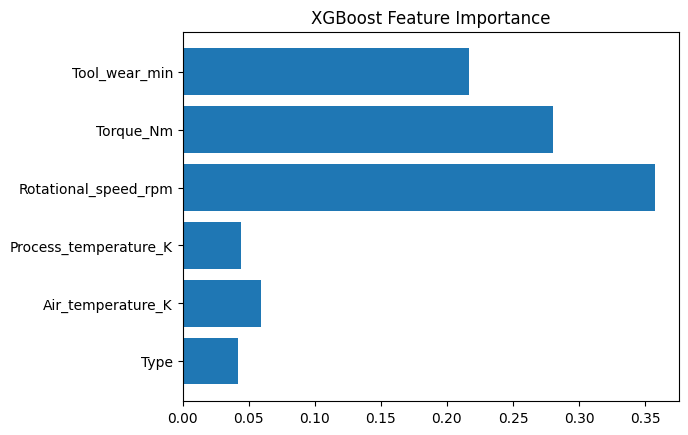

In [ ]:
import matplotlib.pyplot as plt

plt.barh(X_train.columns, xgb.feature_importances_)
plt.title("XGBoost Feature Importance")
plt.show()


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=300)
mlp.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300)

In [ ]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9835
[[1915   17]
 [  16   52]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.76      0.76        68

    accuracy                           0.98      2000
   macro avg       0.87      0.88      0.88      2000
weighted avg       0.98      0.98      0.98      2000



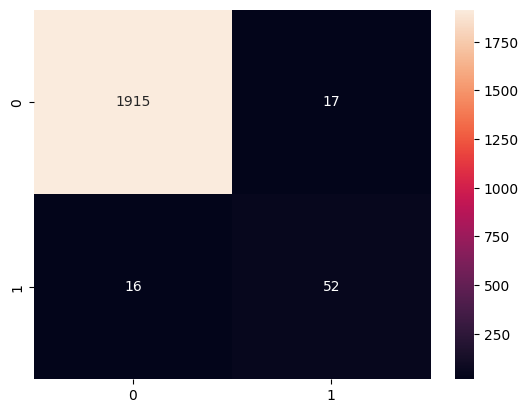

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100,200],
    'max_depth': [5,10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)


GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10], 'n_estimators': [100, 200]})